$$
\providecommand{\bm}{\boldsymbol}
\providecommand{\R}{\mathbb{R}}
\providecommand{\xv}{\mathbf{x}}
\providecommand{\yv}{\mathbf{y}}
\providecommand{\zv}{\mathbf{z}}
$$

## Problem 1: Lagrange multipliers

Solve the constrained optimization problem

$$\min_{(x, y) \in \R^2}\ x + 2y \quad \text{s.t.} \quad x^2 + 4 y^2 = 4$$

by Lagrange multipliers.

**Solution.**

We know that at a minimum $(x^\ast,y^\ast)$ the contour lines of the objective function $f$ and the equality constraint $g$ touch and thus it needs to hold that

$$\nabla f(x^\ast,y^\ast) = \lambda \nabla g(x^\ast,y^\ast)$$

for some Lagrange multiplier $\lambda \in \R$.

Hence, we get the two equalities

$$\begin{aligned} 1 &= \lambda 2 x^\ast \\ 2 &= \lambda 8 y^\ast \end{aligned}$$

yielding $x^\ast = 2 y^\ast$.

The third equality is the equality constraint. It gives

$$\begin{aligned} {x^\ast}^2 + 4{y^\ast}^2 &= 4 \\ \Leftrightarrow \quad 4 {y^\ast}^2 + 4{y^\ast}^2 &= 4 \\ \Leftrightarrow \quad 8 {y^\ast}^2 &= 4 \\ \Leftrightarrow \quad {y^\ast}^2 &= \frac{1}{2}. \end{aligned}$$

Therefore, we have two candidate solutions

$$(x^\ast_1,y^\ast_1) = (\sqrt{2},1/\sqrt{2}) \quad \text{or} \quad (x^\ast_2,y^\ast_2) = (-\sqrt{2},-1/\sqrt{2}).$$

Since $f(x^\ast_1, y^\ast_1) > f(x^\ast_2,y^\ast_2)$, we get the solution

$$(x^\ast,y^\ast) = (-\sqrt{2},-1/\sqrt{2}).$$

## Problem 2: Nonlinear SVM

We have $200$ binary observations from a *moons* distribution (two interleaved half-circles) — not linearly separable. The standard SVM trick: lift to a higher-dimensional feature space via $\phi: \R^d \to \R^l$ and learn a linear separator there. The primal soft-margin SVM in feature space is

$$\min_{\bm{\theta}, \theta_0, \bm{\zeta}}\ \tfrac{1}{2}\|\bm{\theta}\|^2 + C\sum_{i=1}^n \zeta^{(i)} \quad \text{s.t.} \quad y^{(i)}\!\left(\langle \bm{\theta}, \phi(\xv^{(i)})\rangle + \theta_0\right) \geq 1 - \zeta^{(i)},\ \zeta^{(i)} \geq 0\ \forall i.$$

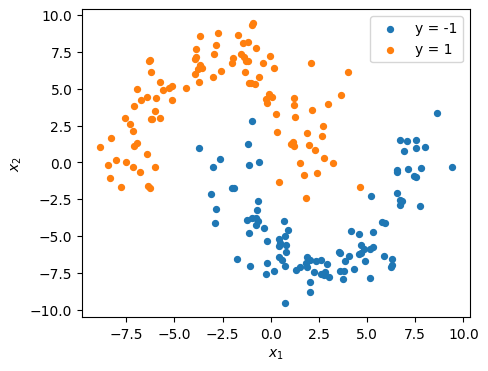

In [1]:
#| label: setup_data
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp

# 200 nonlinearly separable observations from a moons distribution.
data = np.genfromtxt("data/moons.csv", delimiter=",", names=True)
X = np.column_stack([data["x1"], data["x2"]])
y = data["y"].astype(float)
n = X.shape[0]

fig, ax = plt.subplots(figsize=(5, 4))
for label in (-1, 1):
    mask = y == label
    ax.scatter(X[mask, 0], X[mask, 1], label=f"y = {label}", s=18)
ax.set_xlabel(r"$x_1$"); ax.set_ylabel(r"$x_2$")
ax.legend()
plt.show()

### (a) Lagrangian

Write down the Lagrangian of the nonlinear SVM.

**Solution.**

$$\mathcal{L} = 0.5\Vert \bm{\theta} \Vert^2 + C\sum^n_{i=1}\zeta^{(i)} - \sum^n_{i=1}\alpha^{(i)}(\mathbf{y}^{(i)}({\phi(\mathbf{x}^{(i)})}^\top\bm{\theta} + \theta_0) - 1 + \zeta^{(i)})- \sum^n_{i=1}\mu^{(i)}\zeta^{(i)}$$

### (b) Solve the primal SVM

Solve the primal nonlinear SVM with $C = 1$ and a third-order polynomial transformation (without intercept)

$$\phi(\xv) = (x_1, x_2, x_1^2, x_2^2, x_1 x_2, x_1^2 x_2, x_1 x_2^2, x_1^3, x_2^3)^\top \in \R^9$$

using `CVXR` (R) or `cvxpy` (Python).

primal: status = optimal, obj = 0.4163, theta_0 = -0.1928
theta = (+0.839, -0.295, +0.074, +0.062, +0.102, +0.013, +0.061, -0.076, +0.111)


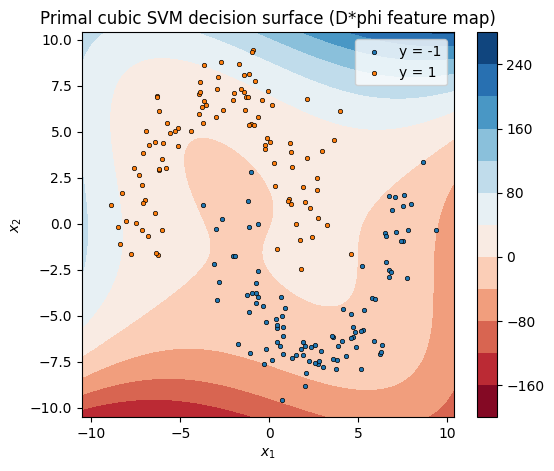

In [2]:
#| label: solution_2b_code
def cubic(X):
    """Cubic polynomial features without intercept (9 components)."""
    x1, x2 = X[:, 0], X[:, 1]
    return np.column_stack([x1, x2,
                            x1**2, x2**2, x1 * x2,
                            x1**2 * x2, x1 * x2**2,
                            x1**3, x2**3])


# Diagonal scaling so that <D phi(x), D phi(z)> = (x^T z + 1)^3 - 1
# (matches the dual kernel in (e)).
D_diag = np.array([np.sqrt(3), np.sqrt(3), np.sqrt(3), np.sqrt(3), np.sqrt(6),
                   np.sqrt(3), np.sqrt(3), 1.0, 1.0])
D = np.diag(D_diag)

Z   = cubic(X)              # raw phi(X); used in (e) when recovering theta
Z_D = Z @ D                 # D*phi(X); used in the primal constraint below
C_val = 1.0

theta0 = cp.Variable()
theta  = cp.Variable(9)
slack  = cp.Variable(n, nonneg=True)

obj = cp.Minimize(0.5 * cp.sum_squares(theta) + C_val * cp.sum(slack))
constraints = [cp.multiply(y, Z_D @ theta + theta0) >= 1 - slack]
prob = cp.Problem(obj, constraints)
prob.solve()

theta0_p = float(theta0.value)
theta_p = theta.value            # theta in D*phi basis
print(f"primal: status = {prob.status}, obj = {prob.value:.4f}, "
      f"theta_0 = {theta0_p:+.4f}")
print("theta = (" + ", ".join(f"{v:+.3f}" for v in theta_p) + ")")

# Decision boundary on a grid
lo, hi = X.min(), X.max()
pad = 0.05 * (hi - lo)
g_grid = np.linspace(lo - pad, hi + pad, 120)
G1, G2 = np.meshgrid(g_grid, g_grid)
G_flat = np.column_stack([G1.ravel(), G2.ravel()])
vals = (cubic(G_flat) @ D @ theta_p + theta0_p).reshape(G1.shape)

fig, ax = plt.subplots(figsize=(6, 5))
cs = ax.contourf(G1, G2, vals, levels=10, cmap="RdBu")
for label in (-1, 1):
    mask = y == label
    ax.scatter(X[mask, 0], X[mask, 1], s=10, edgecolor="k", linewidth=0.5,
               label=f"y = {label}")
ax.set_xlabel(r"$x_1$"); ax.set_ylabel(r"$x_2$"); ax.legend()
ax.set_title("Primal cubic SVM decision surface (D*phi feature map)")
fig.colorbar(cs)
plt.show()

### (c) KKT conditions

State the KKT conditions of the general nonlinear SVM.

**Solution.**

Stationarity

$$\nabla_{\bm{\theta}}\mathcal{L} = \bm{\theta} - \sum^n_{i=1}\alpha^{(i)}\mathbf{y}^{(i)}\phi(\mathbf{x}^{(i)}) = 0$$
$$\nabla_{\theta_0}\mathcal{L} = - \sum^n_{i=1}\alpha^{(i)}\mathbf{y}^{(i)} = 0$$
$$\nabla_{\bm{\zeta}}\mathcal{L} = C\cdot\mathbf{1}_n - \alpha - \mu = 0$$

Primal feasability

$$-(\mathbf{y}^{(i)}({\phi(\mathbf{x}^{(i)})}^\top\bm{\theta} + \theta_0) - 1 + \zeta^{(i)}) \leq 0$$
$$- \zeta^{(i)} \leq 0$$

Dual feasability

$$\mu \geq 0$$
$$\alpha \geq 0$$

Complementary slackness

$$-\mu^{(i)}\zeta^{(i)} = 0 \quad i = 1,\dots,n$$
$$-\alpha^{(i)}(\mathbf{y}^{(i)}({\phi(\mathbf{x}^{(i)})}^\top\bm{\theta} + \theta_0) - 1 + \zeta^{(i)}) = 0 \quad i = 1,\dots, n$$

### (d) Dual form

Derive the dual form of the nonlinear SVM. State an advantage of the dual over the primal.

*Hint:* use the KKT conditions to eliminate the primal variables from the Lagrangian.

**Solution.**

From the KKT conditions it follows that $$\bm{\theta} = \sum^n_{i=1}\alpha^{(i)}\mathbf{y}^{(i)}\phi(\mathbf{x}^{(i)}),$$
$$\sum^n_{i=1}\alpha^{(i)}\mathbf{y}^{(i)} = 0,$$
$$C  - \underbrace{\mu^{(i)}}_{\geq 0} = \alpha^{(i)}  \Rightarrow C \geq \alpha^{(i)} \quad i=1,\dots,n. $$
Plugging these into the Lagrangian gives

$$0.5\Vert  \sum^n_{i=1}\alpha^{(i)}\mathbf{y}^{(i)}\phi(\mathbf{x}^{(i)}) \Vert^2 + \sum^n_{i=1}\mu^{(i)}\zeta^{(i)} + \sum^n_{i=1}\alpha^{(i)}\zeta^{(i)} - \Vert  \sum^n_{i=1}\alpha^{(i)}\mathbf{y}^{(i)}\phi(\mathbf{x}^{(i)}) \Vert^2  + \sum^n_{i=1}\alpha^{(i)} - \sum^n_{i=1}\alpha^{(i)}\zeta^{(i)})- \sum^n_{i=1}\mu^{(i)}\zeta^{(i)}$$
$$= -0.5\Vert  \sum^n_{i=1}\alpha^{(i)}\mathbf{y}^{(i)}\phi(\mathbf{x}^{(i)}) \Vert^2  + \sum^n_{i=1}\alpha^{(i)} =  -0.5  \sum^n_{i=1}\sum^n_{j=1}\alpha^{(i)}\alpha^{(j)}\mathbf{y}^{(i)}\mathbf{y}^{(j)} \langle\phi(\mathbf{x}^{(i)}),\phi(\mathbf{x}^{(j)})\rangle   + \sum^n_{i=1}\alpha^{(i)}$$

Hence, the dual form of the nonlinear SVM is

$$\max_{\alpha}  -0.5  \sum^n_{i=1}\sum^n_{j=1}\alpha^{(i)}\alpha^{(j)}\mathbf{y}^{(i)}\mathbf{y}^{(j)} \langle\phi(\mathbf{x}^{(i)}),\phi(\mathbf{x}^{(j)})\rangle   + \sum^n_{i=1}\alpha^{(i)}$$

s.t.

$$\sum^n_{i=1}\alpha^{(i)}\mathbf{y}^{(i)} = 0,$$
$$0 \leq \alpha \leq C.$$

Here, we can use the kernel trick to evaluate $\langle\phi(\mathbf{x}^{(i)}),\phi(\mathbf{x}^{(j)})\rangle$ without explicitly computing the projections of each observation. (We only need to compute  $\langle\mathbf{x}^{(i)},\mathbf{x}^{(j)}\rangle$)

### (e) Solve the dual SVM

Solve the dual form from (b) via `CVXR`/`cvxpy`.

*Hint 1:* For a polynomial transformation $\phi$ of order $l$ (without intercept) there exists an invertible diagonal $\mathbf{D} \in \R^{l \times l}$ such that $\langle \mathbf{D}\phi(\xv), \mathbf{D}\phi(\zv)\rangle = (\xv^\top \zv + 1)^l - 1$.

*Hint 2:* Add $10^{-7} \mathbf{I}$ to the kernel matrix to ensure invertibility / positive-definiteness.

dual:   status = optimal, obj = 0.4163
recovered: theta_0 = -0.1928, primal/dual obj diff = 7.0105e-09
support vectors: 10 / 200 (alpha_i > 1e-04)


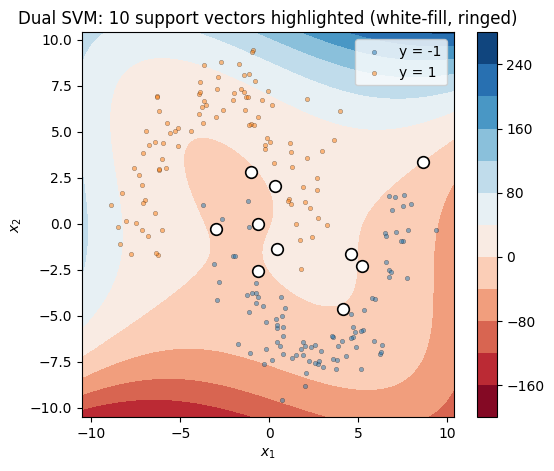

In [3]:
#| label: solution_2e_code
# Kernel: K = (X X^T + 1)^3 - 1.
# Hint 1: <D phi(x), D phi(z)> = (x^T z + 1)^l - 1
K = (X @ X.T + 1) ** 3 - 1
P = np.diag(y) @ K @ np.diag(y) + 1e-7 * np.eye(n)        # Hint 2: ensure PD

alpha = cp.Variable(n, nonneg=True)
obj_d = cp.Maximize(cp.sum(alpha) - 0.5 * cp.quad_form(alpha, cp.psd_wrap(P)))
constraints_d = [alpha @ y == 0, alpha <= C_val]
prob_d = cp.Problem(obj_d, constraints_d)
prob_d.solve()

alpha_p = alpha.value
print(f"dual:   status = {prob_d.status}, obj = {prob_d.value:.4f}")

# Recover theta via the diagonal scaling D matching <D phi, D phi> = K
D = np.diag([np.sqrt(3), np.sqrt(3), np.sqrt(3), np.sqrt(3), np.sqrt(6),
             np.sqrt(3), np.sqrt(3), 1.0, 1.0])
theta_d = (alpha_p * y) @ Z @ D

scores = Z @ D @ theta_d
theta0_d = -0.5 * (scores[y == -1].max() + scores[y == 1].min())
print(f"recovered: theta_0 = {theta0_d:+.4f}, "
      f"primal/dual obj diff = {prob.value - prob_d.value:.4e}")

# Support vectors: alpha_i > eps
# (active margin constraint, by complementary slackness).
sv_eps = 1e-4
sv_mask = alpha_p > sv_eps
print(f"support vectors: {int(sv_mask.sum())} / {n} (alpha_i > {sv_eps:.0e})")

vals_d = (cubic(G_flat) @ D @ theta_d + theta0_d).reshape(G1.shape)
fig, ax = plt.subplots(figsize=(6, 5))
cs = ax.contourf(G1, G2, vals_d, levels=10, cmap="RdBu")
for label in (-1, 1):
    mask_class = y == label
    # Non-support-vector points: faded
    mask_non_sv = mask_class & ~sv_mask
    ax.scatter(X[mask_non_sv, 0], X[mask_non_sv, 1], s=10,
               edgecolor="k", linewidth=0.3, alpha=0.5, label=f"y = {label}")
    # Support vectors: ringed
    mask_sv = mask_class & sv_mask
    ax.scatter(X[mask_sv, 0], X[mask_sv, 1], s=70,
               facecolor="white", edgecolor="k", linewidth=1.2)
ax.set_xlabel(r"$x_1$"); ax.set_ylabel(r"$x_2$"); ax.legend()
ax.set_title(f"Dual SVM: {int(sv_mask.sum())} support vectors "
             f"highlighted (white-fill, ringed)")
fig.colorbar(cs)
plt.show()